# 02 — Vegetation and Ground Materials

Two more layers the SDK can pull for any polygon:

- `client.vegetation.get_area(polygon)` -- street trees as GeoJSON points,
  each with species/height/canopy attributes when available.
- `client.ground_materials.get_area(polygon)` -- surface coverage layers
  (asphalt, concrete, soil, water, vegetation, building footprints) as
  GeoJSON `FeatureCollection`s, one per material.

Both feed into the thermal analyses (UTCI, TCS) and the daylight / solar
radiation analyses, so it's worth knowing what you're sending.

In [1]:
from dotenv import load_dotenv
load_dotenv()

from infrared_sdk import InfraredClient
from cities import get

city = get("munich")
print(f"City: {city.name}")

City: Munich


## Fetch trees

In [2]:
with InfraredClient() as client:
    veg = client.vegetation.get_area(city.polygon_small)

print(f"total_trees : {veg.total_trees}")
sample_id, sample_feat = next(iter(veg.features.items()))
print(f"\nsample id   : {sample_id}")
print(f"sample feat : {sample_feat}")

total_trees : 119

sample id   : node/2501121312
sample feat : {'type': 'Feature', 'id': 'node/2501121312', 'geometry': {'type': 'Point', 'coordinates': [11.572218, 48.136881]}, 'properties': {'natural': 'tree', 'leaf_type': 'broadleaved', 'leaf_cycle': None, 'height': None, 'circumference': None, 'diameter_crown': None, 'species': None}}


Each value is a standard GeoJSON `Feature` with a `Point` geometry in
WGS-84 lat/lon and any tags from the OSM source (height, species, etc.).

## Fetch ground materials

In [3]:
with InfraredClient() as client:
    gm = client.ground_materials.get_area(city.polygon_small)

print(f"total_features  : {gm.total_features}")
print(f"layers present  : {list(gm.layers)}")
for name, fc in gm.layers.items():
    print(f"  {name:12s}: {len(fc.get('features', []))} features")

total_features  : 25
layers present  : ['asphalt', 'building', 'concrete', 'vegetation', 'soil', 'water']
  asphalt     : 1 features
  building    : 0 features
  concrete    : 17 features
  vegetation  : 6 features
  soil        : 0 features
  water       : 1 features


## Visualise everything together

Plot tree positions on top of the surface layers so you can see how the
two map onto each other.

C:\Users\User\AppData\Local\Temp\ipykernel_1244\1385926364.py:49: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", fontsize=8)


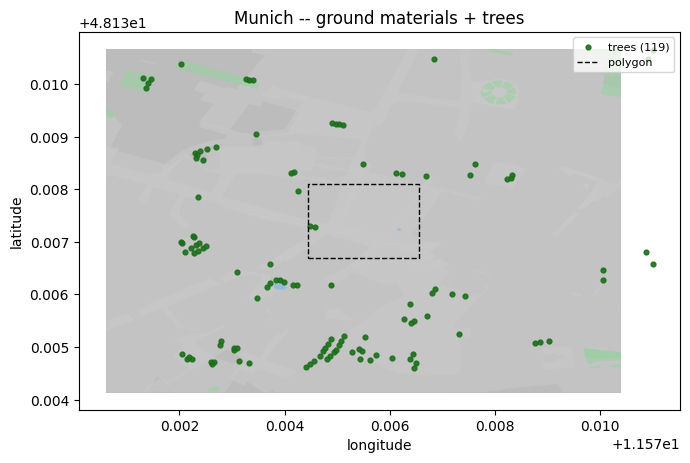

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

_COLORS = {
    "vegetation": "#9bd0a3",
    "water":      "#7eb6e8",
    "asphalt":    "#999999",
    "concrete":   "#c8c8c8",
    "soil":       "#caa472",
    "building":   "#e8a85a",
}

fig, ax = plt.subplots(figsize=(7, 7))
for name, fc in gm.layers.items():
    patches = []
    for feat in fc.get("features", []):
        geom = feat.get("geometry", {})
        rings = []
        if geom.get("type") == "Polygon":
            rings = [geom.get("coordinates", [[]])[0]]
        elif geom.get("type") == "MultiPolygon":
            rings = [p[0] for p in geom.get("coordinates", [])]
        for ring in rings:
            if ring:
                patches.append(MplPolygon([(p[0], p[1]) for p in ring], closed=True))
    if patches:
        ax.add_collection(PatchCollection(
            patches, facecolor=_COLORS.get(name, "#bbb"),
            edgecolor="none", alpha=0.65, label=name))

# Trees on top
import numpy as np
lons, lats = [], []
for feat in veg.features.values():
    coords = (feat.get("geometry") or {}).get("coordinates", [])
    if len(coords) >= 2:
        lons.append(coords[0]); lats.append(coords[1])
if lons:
    ax.scatter(lons, lats, s=12, c="#1b6f1b", alpha=0.9, label=f"trees ({len(lons)})")

# Polygon outline
poly = city.polygon_small["coordinates"][0]
ax.plot([p[0] for p in poly], [p[1] for p in poly], "k--", lw=1, label="polygon")

ax.set_aspect("equal")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"{city.name} -- ground materials + trees")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Passing layers to analyses

Pass the dicts directly to `run_area_and_wait` -- the orchestrator
handles per-tile dedup and assignment:

```python
result = client.run_area_and_wait(
    [payload],
    polygon,
    buildings=area.buildings,
    vegetation=veg.features,           # all trees
    ground_materials=gm.layers,        # all surface layers
)
```

If a layer is empty or you don't have it, pass `{}` (or omit the
keyword). See the README's "Layer parameter behaviour" section for the
full table of cases.

> **Size watchout.** Ground materials can be heavy in dense
> neighbourhoods. If `gm.total_features > ~5000`, consider down-sampling
> or skipping the layer to avoid HTTP 413.

Next: `03_weather_and_time_periods.ipynb`.